**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("xgboost")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("Matrix")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Import table**

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99981   580


Variant_ID,Delta,AC0014:BATF/FOSL:bZIP,AC0078:CTCF/CTCFL:C2H2_ZF,AC0180:ZSCAN/ZNF:C2H2_ZF,AC0241:NFE2L/JUN:bZIP,AC0391:FOXN:Forkhead,AC0403:DBP/HLF:bZIP,AC0404:TIGD:CENPB,AC0411:NR1I/VDR:Nuclear_receptor,AC0445:ZNF:C2H2_ZF,"AC0467:PAX:Homeodomain,Paired_box",AC0542:ZBTB:C2H2_ZF,AC0544:GMEB:SAND,AC0547:ATF/CREB:bZIP,AC0625:ELF:Ets,AC0016:KLF:C2H2_ZF,AC0211:ZNF:C2H2_ZF,AC0247:ZNF:C2H2_ZF,AC0335:NRF:Unknown,AC0376:ZBED:BED_ZF,AC0377:ZNF385D:C2H2_ZF,AC0390:CREB/JUND:bZIP,AC0539:IRX:Homeodomain,AC0540:ASCL:bHLH,AC0628:SMAD:SMAD,AC0246:MAFF/MAF:bZIP,AC0349:IRX:Homeodomain,AC0478:ZNF/PAX:C2H2_ZF,AC0543:PROX:Prospero,AC0549:ZNF:C2H2_ZF,AC0615:ZNF:C2H2_ZF,AC0034:NR2F/NR1H:Nuclear_receptor,AC0218:ZSCAN:C2H2_ZF,AC0248:ZNF:C2H2_ZF,AC0257:FOXG/FOXK:Forkhead,AC0347:ZNF:C2H2_ZF,AC0527:PBX/PKNOX:Homeodomain,AC0203:ZNF:C2H2_ZF,AC0240:ZNF:C2H2_ZF,AC0466:ZNF:C2H2_ZF,AC0471:ZNF:C2H2_ZF,AC0499:ZBTB:C2H2_ZF,AC0510:ZNF:C2H2_ZF,AC0604:ZNF:C2H2_ZF,AC0605:SCRT:C2H2_ZF,AC0609:ZBTB/OLIG:bHLH,AC0367:ZNF:C2H2_ZF,AC0061:YY:C2H2_ZF,AC0156:ZNF:C2H2_ZF,AC0348:TP:p53,AC0472:ZNF:C2H2_ZF,AC0482:ZNF:C2H2_ZF,AC0508:FOSL:bZIP,AC0522:ZKSCAN:C2H2_ZF,AC0202:ZNF:C2H2_ZF,AC0331:YBX:CSD,AC0352:ZNF:C2H2_ZF,AC0386:FOXR:Forkhead,AC0484:ZNF:C2H2_ZF,"AC0537:POU4F:Homeodomain,POU",AC0091:ZNF:C2H2_ZF,AC0318:ZBTB:C2H2_ZF,AC0402:CEBPB/CEBPE:bZIP,AC0083:ZBTB:C2H2_ZF,AC0238:ZNF:C2H2_ZF,AC0419:ESR/ESRRA:Nuclear_receptor,AC0427:NR6A:Nuclear_receptor,AC0430:TCF7L/LEF:Sox,"AC0587:POU5F/NANOG:Homeodomain,POU",AC0620:ZNF:C2H2_ZF,AC0002:PROP/ALX:Homeodomain,AC0102:ZNF:C2H2_ZF,AC0153:ZNF:C2H2_ZF,AC0410:RARA/RARG:Nuclear_receptor,AC0469:ZNF:C2H2_ZF,AC0489:ZNF:C2H2_ZF,AC0532:ZNF:C2H2_ZF,"AC0562:PAX:Homeodomain,Paired_box",AC0077:ZIC/GLIS:C2H2_ZF,AC0413:THRB/RARA:Nuclear_receptor,AC0458:ZFP:C2H2_ZF,AC0470:ZNF:C2H2_ZF,AC0496:ZNF:C2H2_ZF,"AC0560:PAX:Homeodomain,Paired_box",AC0085:ZNF:C2H2_ZF,AC0336:ZNF:C2H2_ZF,AC0041:ZNF:C2H2_ZF,AC0086:ZNF:C2H2_ZF,AC0333:ZNF:C2H2_ZF,AC0393:IRX:Homeodomain,AC0463:ZNF:C2H2_ZF,AC0507:PAX:Paired_box,AC0529:ZNF:C2H2_ZF,AC0603:ZNF:C2H2_ZF,AC0020:CENPB:CENPB,AC0165:ZNF:C2H2_ZF,AC0412:NR1I/NR1H:Nuclear_receptor,AC0415:RARA/ESRRA:Nuclear_receptor,AC0468:ZNF780A:C2H2_ZF,AC0557:PBX/HOXA:Homeodomain,AC0559:MEIS/PBX:Homeodomain,AC0023:ZNF:C2H2_ZF,AC0059:YY/ZFP:C2H2_ZF,AC0242:FOSL/JUND:bZIP,AC0389:FOXN:Forkhead,AC0633:TBX/MGA::EVX:T-box,AC0420:THRA/THRB:Nuclear_receptor,AC0465:ZIK:C2H2_ZF,AC0104:ZNF:C2H2_ZF,AC0301:ZNF:C2H2_ZF,AC0379:FOXK/FOXC:Forkhead,AC0460:ZNF:C2H2_ZF,AC0503:ZNF:C2H2_ZF,AC0555:SREBF:bHLH,AC0064:RFX/MXI:RFX,AC0400:GMEB:SAND,AC0408:RORC/RORA:Nuclear_receptor,AC0421:THRB:Nuclear_receptor,AC0453:ZNF:C2H2_ZF,AC0551:CREB3L/XBP:bZIP,AC0304:ZFP:C2H2_ZF,AC0050:ZNF:C2H2_ZF,AC0113:ZNF:C2H2_ZF,AC0147:ZNF:C2H2_ZF,AC0338:ARID5B:ARID/BRIGHT,AC0488:ZNF:C2H2_ZF,AC0487:ZNF:C2H2_ZF,AC0613:MEIS/PKNOX:Homeodomain,AC0040:ZNF:C2H2_ZF,AC0154:ZNF:C2H2_ZF,AC0407:RXRG/RARB:Nuclear_receptor,AC0409:NR2E:Nuclear_receptor,AC0174:ZSCAN:C2H2_ZF,AC0334:ZNF:C2H2_ZF,AC0464:ZNF:C2H2_ZF,AC0244:MAFG/MAFF:bZIP,AC0356:DMRT/DMRTA:DM,AC0493:ZNF:C2H2_ZF,AC0070:MYB/MYBL:Myb/SANT,AC0632:TBX/MGA:T-box,"AC0561:PAX:Homeodomain,Paired_box",AC0406:ZNF:C2H2_ZF,AC0521:ZNF:C2H2_ZF,AC0530:ZNF:C2H2_ZF,AC0042:ZSCAN:C2H2_ZF,AC0069:ZNF:C2H2_ZF,AC0127:ZFP:C2H2_ZF,AC0130:GCM:GCM,AC0168:ZNF:C2H2_ZF,AC0185:ZNF:C2H2_ZF,AC0273:MTF:C2H2_ZF,AC0360:MYRF:Ndt80/PhoG,AC0370:ZNF/ZNF280A:C2H2_ZF,AC0461:ZNF:C2H2_ZF,AC0032:SIX/ZNF:Homeodomain,AC0556:USF/BHLHE:bHLH,AC0093:ZNF:C2H2_ZF,AC0631:T/TBX:T-box,AC0568:ZNF:C2H2_ZF,AC0617:ERG/FLI:Ets,AC0228:CTCF:C2H2_ZF,"AC0397:POU2F/POU3F:Homeodomain,POU",AC0627:ELF:Ets,AC0172:ZNF:C2H2_ZF,AC0343:ZNF:C2H2_ZF,AC0101:ZBTB:C2H2_ZF,AC0459:ZNF:C2H2_ZF,AC0506:ZNF:['C2H2_zinc_finger_factors'],AC0145:ZNF:C2H2_ZF,AC0236:BATF/IRF:bZIP,AC0239:BACH/NFE:bZIP,AC0243:ZSCAN5C:C2H2_ZF,AC0369:ZNF:C2H2_ZF,AC0417:NR2E:Nuclear_receptor,AC0065:RFX:RFX,AC0060:YY/MZF:C2H2_ZF,AC0223:ZNF:C2H2_ZF,AC0302:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0365:ZIM/ZNF:C2H2_ZF,AC0366:ZNF:C2H2_ZF,AC0491:ZNF:C2H2_ZF,AC0492:ZNF:C2H2_ZF,AC0285

In [5]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_cv05fold.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)

### assign and show
fit_xgb_cv = obj
print(obj)

##### xgb.cv 5-folds
  iter train_rmse_mean train_rmse_std test_rmse_mean test_rmse_std
 <num>           <num>          <num>          <num>         <num>
     1      0.44082753   3.296880e-05     0.44083021  0.0001342577
     2      0.41884118   3.072638e-05     0.41884723  0.0001395768
     3      0.39795591   2.740073e-05     0.39796789  0.0001437166
     4      0.37811727   2.652821e-05     0.37813419  0.0001478649
     5      0.35927382   2.582062e-05     0.35929603  0.0001501389
   ---             ---            ---            ---           ---
   696      0.01559369   9.409544e-05     0.02127746  0.0005811636
   697      0.01558895   9.477930e-05     0.02127762  0.0005814809
   698      0.01558642   9.408008e-05     0.02127801  0.0005817149
   699      0.01558392   9.426580e-05     0.02127792  0.0005812619
   700      0.01557976   9.487117e-05     0.02127772  0.0005803416
Best iteration:
  iter train_rmse_mean train_rmse_std test_rmse_mean test_rmse_std
 <num>           <num>   

In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifmodel_pilot_jvierstra_v2.1beta")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.pilot.XY_full.xgb_model.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
obj = read_rds(txt_fpath)
obj = xgb.Booster.complete(obj)

### assign and show
fit_xgb_final = obj
print(obj)

##### xgb.Booster
raw: 1.3 Mb 
call:
  xgb.train(params = lst_param, data = dat_train, nrounds = best_nrounds, 
    watchlist = watchlist, verbose = 0)
params (as set within xgb.train):
  booster = "gbtree", objective = "reg:squarederror", eval_metric = "rmse", eta = "0.05", max_depth = "5", subsample = "0.8", colsample_bytree = "0.8", validate_parameters = "TRUE"
xgb.attributes:
  niter
callbacks:
  cb.evaluation.log()
# of features: 578 
niter: 649
nfeatures : 578 
evaluation_log:
  iter train_rmse
 <num>      <num>
     1 0.44082634
     2 0.41883972
   ---        ---
   649 0.01605747
   650 0.01605518


## arrange table

In [7]:
### init: get data for XY
dat = dat_XY

### keep variant ID separately
vec_txt_variant = dat$Variant_ID

### response variable
y = dat$Delta

### feature matrix
X = dat %>% dplyr::select(-Variant_ID, -Delta)

### convert to numeric matrix
X_mat = as.matrix(X)

dat_train = xgb.DMatrix(data = X_mat, label = y)

## Delta

In [8]:
### get the variant and delta (BlueSTARR)
dat = dat_XY
dat = dat %>% dplyr::select(Variant_ID, Delta) %>% dplyr::arrange(desc(Delta))

### assign and show
dat_Y = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99981     2


Variant_ID,Delta
chr4:74487586:A:G:C,0.9649841
chr9:135685432:G:G:C,0.9454227
chr1:173251490:G:G:C,0.9101272


In [9]:
dat = dat_Y
vec = dat$Variant_ID

vec_txt_variant_sort = vec
print(length(vec))
head(vec, 3)

[1] 99981


[1] "chr4:74487586:A:G:C"  "chr9:135685432:G:G:C" "chr1:173251490:G:G:C"

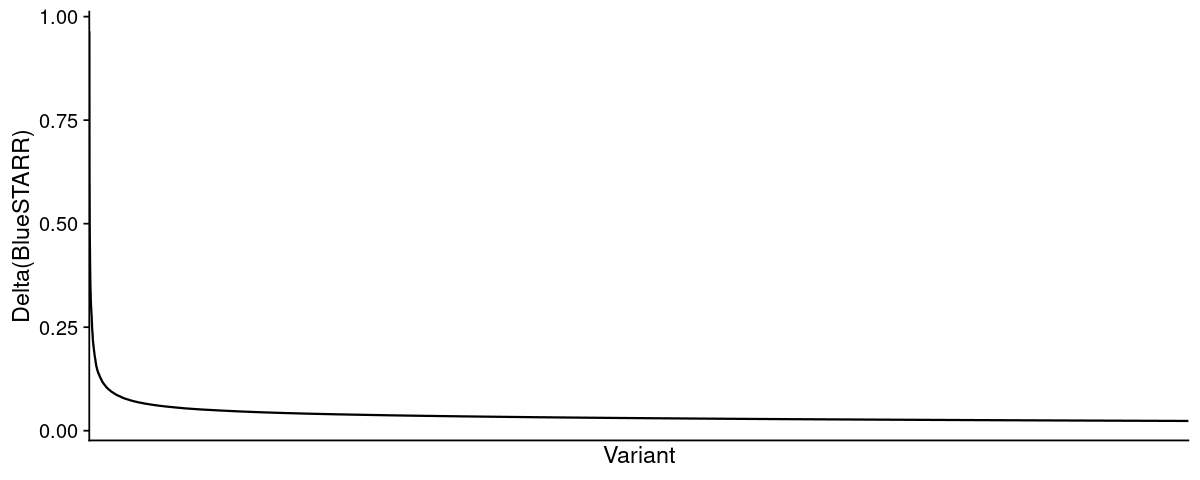

In [10]:
### init
dat = dat_Y

### order variants
dat = dat %>% dplyr::mutate(Variant_ID = factor(Variant_ID, levels=vec_txt_variant_sort))

###
theme_custom = theme(
    axis.ticks.x = element_blank(),
    axis.text.x  = element_blank() 
)
gpt = ggplot(dat, aes(x=Variant_ID, y = Delta, group=1)) +
    geom_line() +
    theme_cowplot() +
    theme_custom +
    labs(x = "Variant", y = "Delta(BlueSTARR)")

###
gpt_Y = gpt
options(repr.plot.height=4, repr.plot.width=10)
print(gpt)

## CV

In [11]:
num_best_iter = fit_xgb_cv$best_iteration
print(num_best_iter)

[1] 650


In [12]:
### get the training log
fit = fit_xgb_cv
dat = fit$evaluation_log

### assign and show
dat_log_cv = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 700   5


iter,train_rmse_mean,train_rmse_std,test_rmse_mean,test_rmse_std
1,0.4408275,3.30e-05,0.4408302,0.0001343
2,0.4188412,3.07e-05,0.4188472,0.0001396
3,0.3979559,2.74e-05,0.3979679,0.0001437
4,0.3781173,2.65e-05,0.3781342,0.0001479
5,0.3592738,2.58e-05,0.3592960,0.0001501
6,0.3413744,2.51e-05,0.3414018,0.0001499


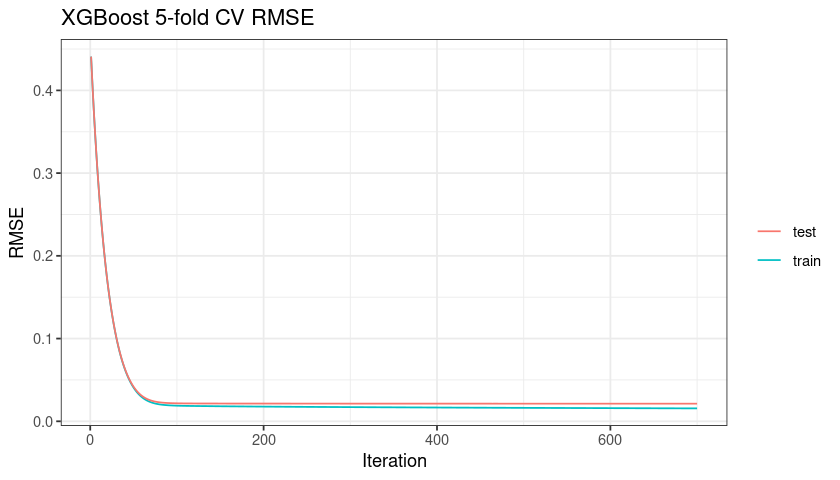

In [13]:
dat = dat_log_cv
gpt = ggplot(dat, aes(x = iter)) +
    geom_line(aes(y = train_rmse_mean, colour = "train")) +
    geom_line(aes(y = test_rmse_mean,  colour = "test")) +
    labs(x = "Iteration",
       y = "RMSE",
       colour = "",
       title = "XGBoost 5-fold CV RMSE") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

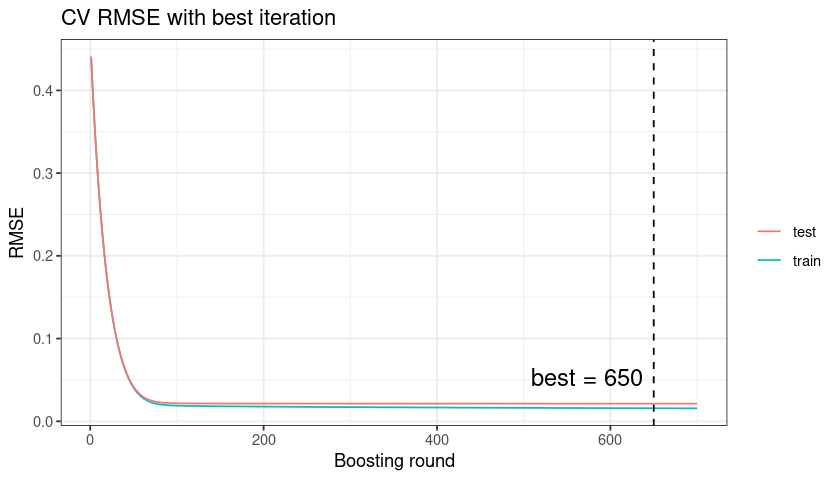

In [14]:
dat = dat_log_cv
gpt = ggplot(dat, aes(x = iter)) +
  geom_line(aes(y = train_rmse_mean, colour = "train")) +
  geom_line(aes(y = test_rmse_mean,  colour = "test")) +
  geom_vline(xintercept = num_best_iter, linetype = 2) +
  annotate(
      "text", 
      x = num_best_iter, 
      y = min(dat$test_rmse_mean),
      label = paste("best =", num_best_iter), 
      vjust = -1, 
      hjust =  1.1,
      size  = 5) +
  labs(x = "Boosting round", 
       y = "RMSE", 
       colour = "",
       title = "CV RMSE with best iteration") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

## Final model

In [22]:
class(fit_xgb_final)

[1] "xgb.Booster"

In [24]:
fit$evaluation_log

NULL

In [14]:
### get the training log
fit = fit_xgb_final
dat = fit$evaluation_log

### assign and show
dat_log_final = dat
print(dim(dat))
fun_display_table(head(dat))

[1] 609   2


iter,train_rmse
1,0.4408277
2,0.4188431
3,0.3979593
4,0.3781216
5,0.3592764
6,0.3413817


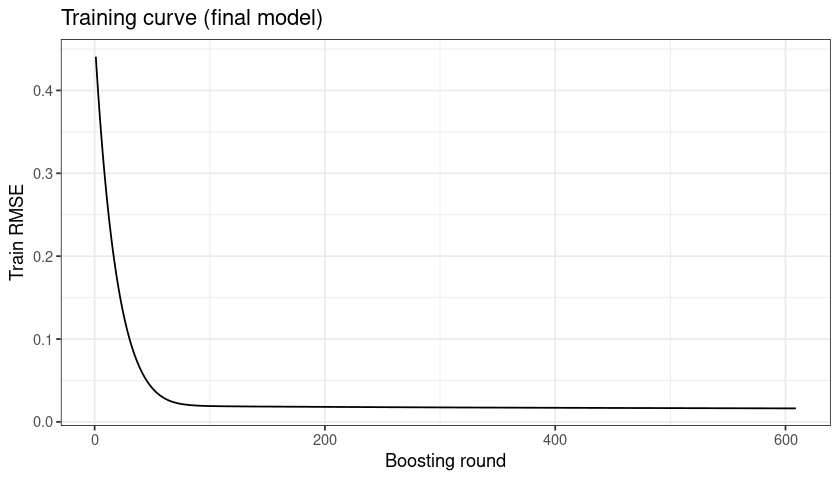

In [15]:
dat = dat_log_final
gpt = ggplot(dat, aes(x = iter, y = train_rmse)) +
  geom_line() +
  labs(x = "Boosting round",
       y = "Train RMSE",
       title = "Training curve (final model)") +
  theme_bw()

options(repr.plot.height = 4, repr.plot.width = 7)
print(gpt)

In [ ]:
imp_xgb = xgb.importance(
  model = fit_xgb_final,
  feature_names = colnames(X_mat)
)

xgb.plot.importance(imp_xgb[1:30, ])  # top 30 motifs

```
Predicted vs observed

Residuals vs predicted

Histogram of residuals

Feature importance

SHAP beeswarm plot

SHAP dependence plot for top motifs
```

## Basic diagnostics: predicted vs observed, residuals

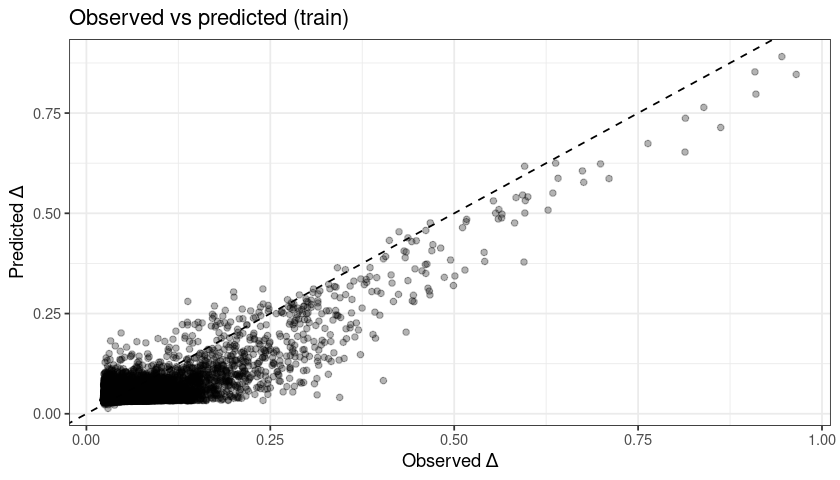

In [20]:
y_true  = y
y_pred  = predict(fit_xgb_final, dat_train)
dat_diag = data.frame(y_true = y_true, y_pred = y_pred)

ggplot(dat_diag, aes(x = y_true, y = y_pred)) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  labs(x = "Observed Δ",
       y = "Predicted Δ",
       title = "Observed vs predicted (train)") +
  theme_bw()

In [21]:
dat_diag$resid = dat_diag$y_true - dat_diag$y_pred

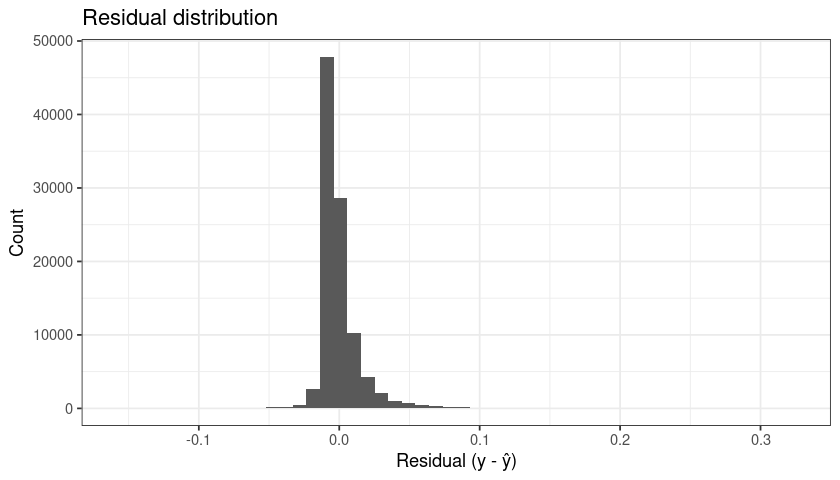

In [22]:
# Histogram
ggplot(dat_diag, aes(x = resid)) +
  geom_histogram(bins = 50) +
  labs(x = "Residual (y - ŷ)",
       y = "Count",
       title = "Residual distribution") +
  theme_bw()

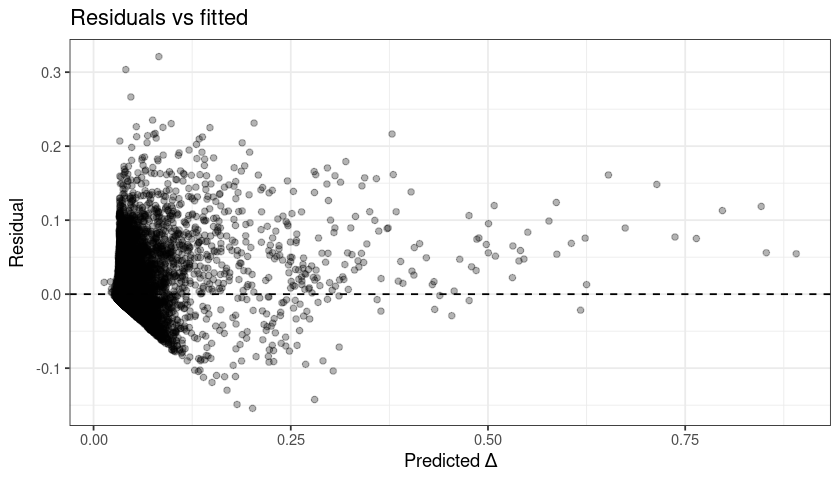

In [23]:
# Residual vs fitted
ggplot(dat_diag, aes(x = y_pred, y = resid)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, linetype = 2) +
  labs(x = "Predicted Δ",
       y = "Residual",
       title = "Residuals vs fitted") +
  theme_bw()

## Feature importance & SHAP plots

### XGBoost feature importance
This is a classic “overall importance” view (not as nuanced as SHAP, but easy to sanity check).

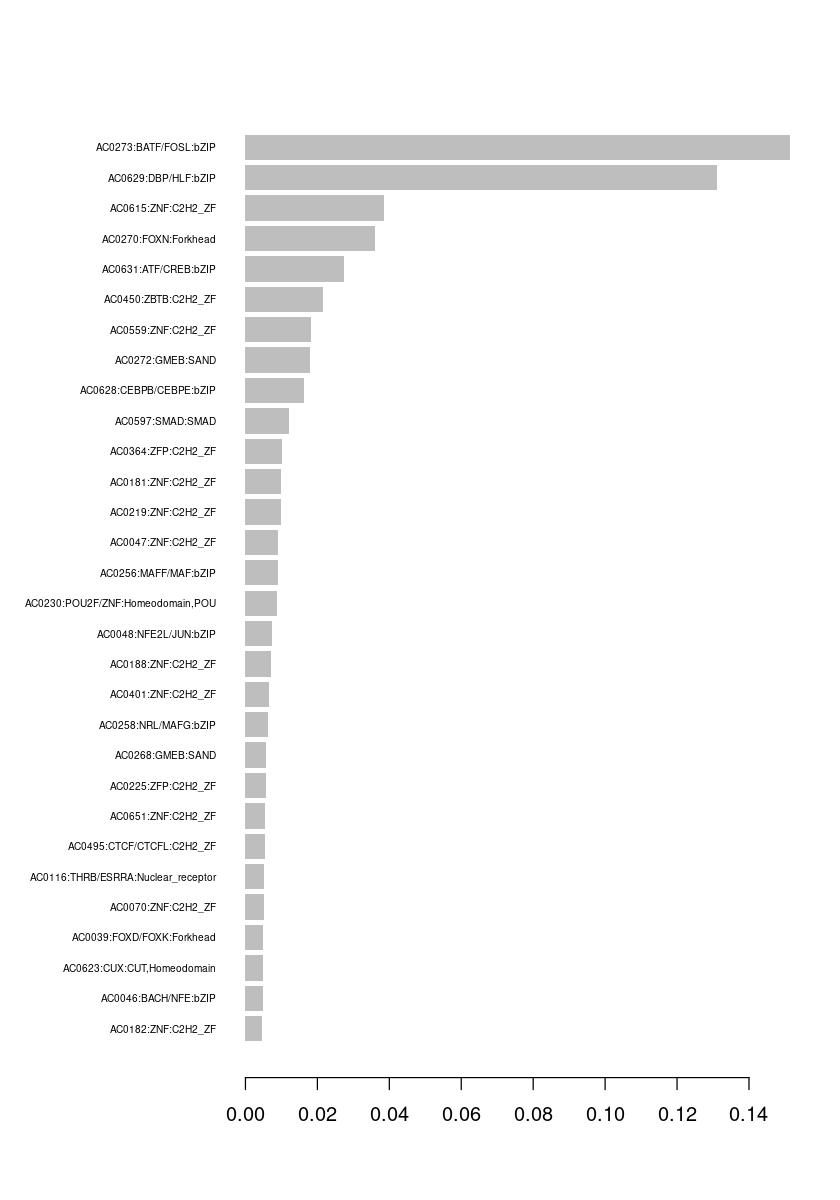

In [25]:
imp_xgb = xgb.importance(
  model = fit_xgb_final,
  feature_names = colnames(X_mat)
)
options(repr.plot.height = 10, repr.plot.width = 7)
xgb.plot.importance(imp_xgb[1:30, ])  # top 30 motifs

### SHAP summary plot
Global SHAP summary (per-feature importance + distribution):

In [ ]:
shap.plot.summary(
  shap_contrib = lst_shap_value$shap_score,
  X = X_mat
)

```
# SHAPforxgboost already designed shap.plot.summary() mainly for matrix,
# but you can also use dat_shap_long_arrange directly:

shap.plot.summary.dat(dat_shap_long_arrange)
# (this helper exists in newer versions; if not, stick to shap_contrib + X)
```

## SHAP dependence plot for specific motifs

Pick a motif, for example “AC0629:DBP/HLF:bZIP”:

In [ ]:
otif_name = "AC0629:DBP/HLF:bZIP"

shap.plot.dependence(
  xgb_model   = fit_xgb_final,
  X_train     = X_mat,
  shap_contrib = lst_shap_value$shap_score,
  x           = motif_name
)

Or for two-way interactions (e.g., DBP vs AP-1 motif):

In [ ]:
shap.plot.dependence(
  xgb_model   = fit_xgb_final,
  X_train     = X_mat,
  shap_contrib = lst_shap_value$shap_score,
  x           = "AC0629:DBP/HLF:bZIP",
  y           = "MA0099.4 FOS::JUN"
)

A complete diagnostics code block

including all the following plots:

Predicted vs observed scatter with R²

Residual histogram

Residual vs predicted

Feature importance (gain, cover, weight)

SHAP summary beeswarm

SHAP dependence plot for top k motifs

Below is a complete, ready-to-run diagnostic script for your XGBoost gain-only model.
It includes:

Loading the model (+ restoring pointer)

Loading X_mat, y, Variant_ID

Predicted vs Observed

Residual analysis

Feature importance plots

SHAP values (summary + top motifs)

Optional: save all plots

I structured it so you can cleanly paste into an R notebook or script.m

✔ Predicted vs observed

Shows model correlation with ground truth.

✔ Residuals vs predicted

Shows if variance is unequal, or systematic bias.

✔ Histogram of residuals

Shows distribution & outliers.

✔ Feature importance

Top motifs by XGBoost Gain.

✔ SHAP summary plot

Your real motif-level importance across all variants.

✔ SHAP dependence plot for the top motif

Shows how motif strength influences Δ.

In [ ]:
suppressMessages(library(tidyverse))
suppressMessages(library(xgboost))
suppressMessages(library(SHAPforxgboost))
suppressMessages(library(ggplot2))

###------------------------------------------------------------
### 1. Load Model + Restore Pointer
###------------------------------------------------------------

txt_fdiry = file.path(
    FD_RES,
    "analysis_variant_motif_richard",
    "motifdelta_pilot_jvierstra_v2.0beta"
)

txt_fpath_model = file.path(
    txt_fdiry,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_model.rds"
)

fit_xgb_final = read_rds(txt_fpath_model)
fit_xgb_final = xgb.Booster.complete(fit_xgb_final)
print(fit_xgb_final)


###------------------------------------------------------------
### 2. Load Data (needed for diagnostics)
###------------------------------------------------------------

txt_fpath_XY = file.path(
    txt_fdiry,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"
)

dat_XY = read_tsv(txt_fpath_XY, show_col_types = FALSE)

y  = dat_XY$Delta
X  = dat_XY %>% dplyr::select(-Variant_ID, -Delta)
X_mat = as.matrix(X)
variant_ids = dat_XY$Variant_ID


###------------------------------------------------------------
### 3. Predictions & Residuals
###------------------------------------------------------------

pred = predict(fit_xgb_final, X_mat)
res  = y - pred

df_eval = tibble(
    Variant_ID = variant_ids,
    Observed   = y,
    Predicted  = pred,
    Residual   = res
)

###------------------------------------------------------------
### 4. Plot: Predicted vs Observed
###------------------------------------------------------------

g_pred_vs_obs = ggplot(df_eval, aes(x = Observed, y = Predicted)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    labs(
        title = "Predicted vs Observed Δ",
        x = "Observed Δ",
        y = "Predicted Δ"
    ) +
    theme_bw()

print(g_pred_vs_obs)


###------------------------------------------------------------
### 5. Plot: Residuals vs Predicted
###------------------------------------------------------------

g_res_vs_pred = ggplot(df_eval, aes(x = Predicted, y = Residual)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_hline(yintercept = 0, color = "red") +
    labs(
        title = "Residuals vs Predicted",
        x = "Predicted Δ",
        y = "Residual"
    ) +
    theme_bw()

print(g_res_vs_pred)


###------------------------------------------------------------
### 6. Plot: Histogram of Residuals
###------------------------------------------------------------

g_hist_res = ggplot(df_eval, aes(x = Residual)) +
    geom_histogram(bins = 60, fill = "steelblue", alpha = 0.7) +
    labs(
        title = "Histogram of Residuals",
        x = "Residual",
        y = "Count"
    ) +
    theme_bw()

print(g_hist_res)


###------------------------------------------------------------
### 7. Feature Importance (Gain / Cover / Frequency)
###------------------------------------------------------------

imp = xgb.importance(model = fit_xgb_final)

g_imp_gain = xgb.plot.importance(imp, top_n = 30, measure = "Gain") +
    ggtitle("Top 30 Features by Gain")

print(g_imp_gain)

### Other measures:
# xgb.plot.importance(imp, top_n = 30, measure = "Cover")
# xgb.plot.importance(imp, top_n = 30, measure = "Frequency")


###------------------------------------------------------------
### 8. SHAP Values
###------------------------------------------------------------

shap_res = shap.values(xgb_model = fit_xgb_final, X_train = X_mat)
shap_long = shap.prep(
    shap_contrib = shap_res$shap_score,
    X_train      = X_mat
)

# Add Variant ID
shap_long = shap_long %>% mutate(Variant_ID = variant_ids[ID])

### SHAP summary (beeswarm)
g_shap_summary = shap.plot.summary(shap_long)
print(g_shap_summary)


###------------------------------------------------------------
### 9. SHAP Dependence Plot (Top Motif)
###------------------------------------------------------------

top_motif = shap_res$mean_shap_score %>%
    sort(decreasing = TRUE) %>%
    names() %>%
    .[1]  # the top motif name

cat("Top motif:", top_motif, "\n")

g_shap_dependence = shap.plot.dependence(
    data_long = shap_long,
    x = top_motif,
    color_feature = top_motif
)

print(g_shap_dependence)


###------------------------------------------------------------
### 10. (Optional) SAVE the plots
###------------------------------------------------------------

# ggsave("pred_vs_obs.png", g_pred_vs_obs, width = 6, height = 5)
# ggsave("residuals_vs_pred.png", g_res_vs_pred, width = 6, height = 5)
# ggsave("hist_residuals.png", g_hist_res, width = 6, height = 5)
# ggsave("shap_summary.png", g_shap_summary, width = 7, height = 6)
# ggsave("shap_dependence_top1.png", g_shap_dependence, width = 6, height = 5)


here is a clean, publication-ready figure panel that combines your most important diagnostics into one unified layout suitable for a manuscript, talk, or thesis.

The panel includes:

A. Cross-validation curve (train/test RMSE)
B. Predicted vs Observed (Δ)
C. Feature Importance (Gain)
D. SHAP Summary (beeswarm)

This gives a complete picture of:

model generalization

accuracy

motif-level contributions

In [ ]:
suppressMessages(library(tidyverse))
suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr))
suppressMessages(library(xgboost))
suppressMessages(library(SHAPforxgboost))

###------------------------------------------------------------
### 0. Load model and data
###------------------------------------------------------------

dir_base <- file.path(
    FD_RES,
    "analysis_variant_motif_richard",
    "motifdelta_pilot_jvierstra_v2.0beta"
)

# Load best model (RDS so evaluation_log is available)
fit <- readRDS(file.path(
    dir_base,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_model.rds"
))
fit <- xgb.Booster.complete(fit)

# Load XY table
dat_XY <- read_tsv(
    file.path(dir_base, "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full.tsv"),
    show_col_types = FALSE
)

# Prepare matrices
y  <- dat_XY$Delta
X  <- dat_XY %>% select(-Variant_ID, -Delta)
X_mat <- as.matrix(X)
variant_ids <- dat_XY$Variant_ID


###------------------------------------------------------------
### A. Cross-validation curve
###------------------------------------------------------------

# Load CV object
fit_cv <- readRDS(file.path(
    dir_base,
    "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_full_xgb_cv05fold.rds"
))

num_best <- fit_cv$best_iteration
dat_cv <- fit_cv$evaluation_log

g_cv <- ggplot(dat_cv, aes(x = iter)) +
    geom_line(aes(y = train_rmse_mean, color = "Train")) +
    geom_line(aes(y = test_rmse_mean,  color = "Test")) +
    geom_vline(xintercept = num_best, linetype = 2) +
    annotate("text",
             x = num_best,
             y = min(dat_cv$test_rmse_mean),
             label = paste("best =", num_best),
             hjust = -0.1, vjust = -1) +
    scale_color_manual(values = c("Train" = "steelblue", "Test" = "firebrick")) +
    labs(title = "A. Cross-validation RMSE",
         x = "Iteration",
         y = "RMSE",
         color = "") +
    theme_bw() +
    theme(legend.position = "top")


###------------------------------------------------------------
### B. Predicted vs Observed
###------------------------------------------------------------

pred <- predict(fit, X_mat)
df_eval <- tibble(Observed = y, Predicted = pred)

g_pred <- ggplot(df_eval, aes(x = Observed, y = Predicted)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_abline(slope = 1, intercept = 0, color = "red") +
    labs(title = "B. Predicted vs Observed Δ",
         x = "Observed Δ",
         y = "Predicted Δ") +
    theme_bw()


###------------------------------------------------------------
### C. Feature Importance (top 20 by Gain)
###------------------------------------------------------------

imp <- xgb.importance(model = fit)
imp_top20 <- imp %>% slice_head(n = 20)

g_imp <- xgb.plot.importance(imp_top20, measure = "Gain") +
    ggtitle("C. Top 20 Motifs by XGBoost Gain") +
    theme_bw() +
    theme(axis.text.y = element_text(size = 7))


###------------------------------------------------------------
### D. SHAP summary plot (beeswarm)
###------------------------------------------------------------

shap_res <- shap.values(xgb_model = fit, X_train = X_mat)
shap_long <- shap.prep(
    shap_contrib = shap_res$shap_score,
    X_train      = X_mat
)

g_shap <- shap.plot.summary(shap_long) +
    ggtitle("D. SHAP Summary (Motif Contributions)")


###------------------------------------------------------------
### Combine into a 2x2 panel
###------------------------------------------------------------

panel <- ggarrange(
    g_cv, g_pred, g_imp, g_shap,
    labels = NULL,
    ncol = 2, nrow = 2,
    heights = c(1, 1.2)
)

print(panel)


###------------------------------------------------------------
### Optionally save as PDF
###------------------------------------------------------------
# ggsave(file.path(dir_base, "figure_panel_xgb_diagnostics.pdf"),
#        panel, width = 14, height = 12)
